
# Hotel Booking Demand - Data Cleanup and Preparation for Machine Learning

**Original dataset URL:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand  
**Preferred local raw file:** `hotel_bookings.csv`  
**Notebook fallback if local file is missing:** a public CSV mirror of the same dataset

## Assignment goals
This notebook demonstrates the full cleanup and preparation workflow on the **Hotel Booking Demand** dataset. It follows the class requirements:

- split the raw dataset into **training (70%)** and **testing (30%)**
- perform **EDA only on the training data**
- handle **NaN / null values**
- apply **feature engineering**
- apply **encoding / one-hot encoding**
- apply **normalization** to reduce skew on selected features
- apply **scaling** to place numeric values on a comparable range
- show the dataset **before and after** cleanup
- save the final clean datasets for later machine learning use

## ML problem proposal
A strong machine learning problem for this dataset is **binary classification**:

- **Target variable:** `is_canceled`
- **Goal:** predict whether a hotel booking will be canceled before arrival
- **Why it matters:** a hotel could use this prediction to adjust staffing, pricing, overbooking risk, promotions, and customer follow-up


In [ ]:

# Import the main libraries we need for data handling, plotting, splitting, and preprocessing.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the utility used to split the raw dataset into training and testing sets.
from sklearn.model_selection import train_test_split
from IPython.display import display

# Import tools used to build a clean preprocessing pipeline.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

# Display settings make tables easier to read inside the notebook.
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# This line tells matplotlib to show charts directly inside the notebook.
%matplotlib inline


In [ ]:
# Store the original dataset URL in a variable so it is visible and documented in the notebook.
dataset_url = "https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand"

# Store a public mirror of the same CSV so the notebook can still run
# when the raw file is not already sitting beside the notebook.
fallback_csv_url = "https://raw.githubusercontent.com/salves94/hotel-exploratory-data-analysis/master/hotel_bookings.csv"

# Print both locations so the source is clearly documented.
print("Original dataset URL:", dataset_url)
print("Fallback CSV mirror:", fallback_csv_url)


Original dataset URL: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
Fallback CSV mirror: https://raw.githubusercontent.com/salves94/hotel-exploratory-data-analysis/master/hotel_bookings.csv


In [ ]:
# Import the Path class so we can search for the CSV file in common notebook locations.
from pathlib import Path

# Build a list of possible places where the raw CSV might exist.
# This makes the notebook work whether the file is in the same folder,
# in /mnt/data, or uploaded elsewhere in a notebook environment.
possible_paths = [
    Path("hotel_bookings.csv"),
    Path("./hotel_bookings.csv"),
    Path("/mnt/data/hotel_bookings.csv"),
    Path.cwd() / "hotel_bookings.csv",
]

# Start with no resolved path and then search the candidate locations.
resolved_path = None
for candidate in possible_paths:
    if candidate.exists():
        resolved_path = candidate
        break

# If we found a local file, read it from disk exactly as provided.
if resolved_path is not None:
    print(f"Loading local dataset from: {resolved_path}")
    raw_df = pd.read_csv(resolved_path)

# If we did not find a local copy, load the CSV from the public mirror.
# This keeps the original Kaggle source documented while allowing the notebook to run.
else:
    print("Local hotel_bookings.csv was not found.")
    print("Loading the dataset from the fallback CSV mirror instead...")
    raw_df = pd.read_csv(fallback_csv_url)

# Show the number of rows and columns in the raw dataset.
print("Raw dataset shape:", raw_df.shape)

# Display the first few rows so we can see the raw data before any cleanup.
raw_df.head()


Local hotel_bookings.csv was not found.
Loading the dataset from the fallback CSV mirror instead...
Raw dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:

# Display basic information about the raw dataset, including column names, data types, and null counts.
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:

# Count missing values in every column so we know what needs to be cleaned.
missing_values = raw_df.isnull().sum().sort_values(ascending=False)

# Display only the columns that actually contain missing values.
missing_values[missing_values > 0]


,0
company,112593
agent,16340
country,488
children,4



## 1) Split the raw dataset first

To avoid **data leakage**, we split the dataset **before** doing EDA and preprocessing.

- **Training data:** 70%
- **Testing data:** 30%

The split is stratified by `is_canceled` so the class balance stays very similar in both sets.


In [ ]:

# Split the raw dataset into a training set and a testing set.
# test_size=0.30 means 30% goes to the testing set.
# random_state=42 makes the split reproducible.
# stratify=raw_df["is_canceled"] keeps the cancellation ratio similar in both sets.
train_df, test_df = train_test_split(
    raw_df,
    test_size=0.30,
    random_state=42,
    stratify=raw_df["is_canceled"]
)

# Print the shapes of both datasets so we can verify the split.
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

# Show the cancellation rate in both sets to verify the stratified split worked correctly.
print("Training cancellation rate:", train_df["is_canceled"].mean())
print("Testing cancellation rate:", test_df["is_canceled"].mean())


Training shape: (83573, 32)
Testing shape: (35817, 32)
Training cancellation rate: 0.3704186758881457
Testing cancellation rate: 0.3704106988301644



## 2) EDA on training data only

All exploration below is performed **only on the training dataset**.
The testing dataset remains untouched until the same transformations are applied later.


In [ ]:

# Show a preview of the raw training data before cleanup.
train_df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
62422,City Hotel,1,277,2017,January,2,13,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,7.0,NaN,0,Transient,59.91,0,0,Canceled,2016-04-11
22069,Resort Hotel,0,52,2016,March,12,15,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,D,0,No Deposit,240.0,NaN,0,Transient,54.00,1,1,Check-Out,2016-03-17
39169,Resort Hotel,0,183,2017,August,32,9,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,D,E,0,No Deposit,NaN,251.0,0,Transient-Party,141.00,0,1,Check-Out,2017-08-10
6140,Resort Hotel,0,225,2016,May,22,26,1,3,1,0.0,0,BB,GBR,Groups,Direct,0,0,0,A,A,2,No Deposit,NaN,223.0,0,Transient-Party,60.00,0,0,Check-Out,2016-05-30
33105,Resort Hotel,0,0,2017,February,7,17,0,2,2,0.0,0,BB,PRT,Direct,Direct,1,0,1,E,E,0,No Deposit,NaN,NaN,0,Transient,8.00,0,0,Check-Out,2017-02-19


In [ ]:

# Summarize the missing values in the training data only.
train_missing = train_df.isnull().sum().sort_values(ascending=False)

# Display only the training columns that contain missing values.
train_missing[train_missing > 0]


,0
company,78800
agent,11474
country,357
children,4


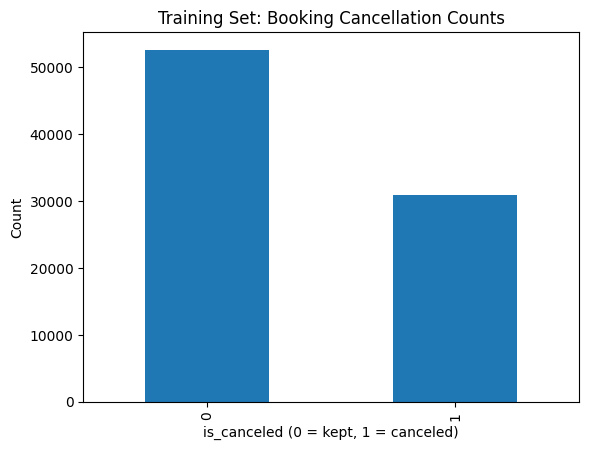

In [ ]:

# Create a simple bar chart showing how many bookings were canceled versus not canceled in the training set.
train_df["is_canceled"].value_counts().sort_index().plot(kind="bar", title="Training Set: Booking Cancellation Counts")
plt.xlabel("is_canceled (0 = kept, 1 = canceled)")
plt.ylabel("Count")
plt.show()


The histogram below helps virsualize the lead_time variable in the training dataset. It shows the relationship between frequency and distribution of lead time and helps identifiy the pattern of outliers. It is a right skewed distribution, which mean most of the booking have short lead time.

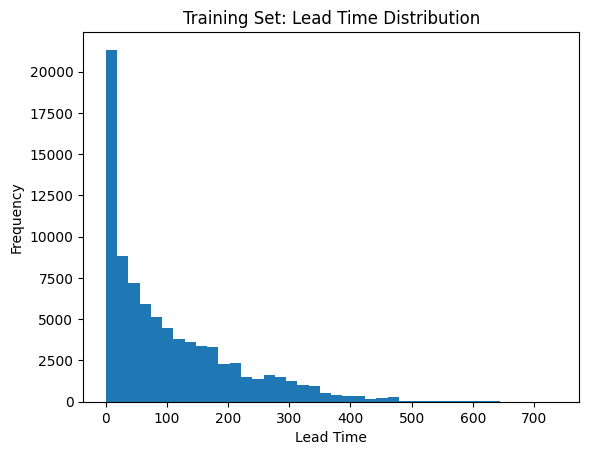

In [ ]:

# Plot the distribution of lead time in the training set to see whether it is skewed.
train_df["lead_time"].plot(kind="hist", bins=40, title="Training Set: Lead Time Distribution")
plt.xlabel("Lead Time")
plt.show()


The histogram below helps virsualize the adr (average daily rate) variable in the training dataset. It also shows as a right skewed distribution, which means smaller number of booking have a higher rate.

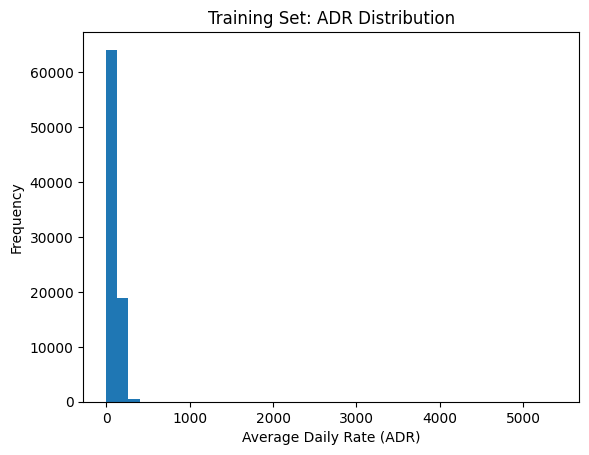

In [ ]:

# Plot the distribution of average daily rate to inspect price spread and skew.
train_df["adr"].plot(kind="hist", bins=40, title="Training Set: ADR Distribution")
plt.xlabel("Average Daily Rate (ADR)")
plt.show()



## 3) Define a feature engineering function

This function adds new features before encoding and scaling:

- `total_guests` = adults + children + babies
- `total_nights` = weekday nights + weekend nights
- `has_agent` = whether an agent was used
- `has_company` = whether a company booking was used
- `arrival_month_num` = month converted from text to number
- `is_family` = whether children or babies are present

It also removes **leakage columns** that should not be used to predict cancellations:

- `reservation_status`
- `reservation_status_date`

Those fields reflect information that is known **after** the booking outcome, so using them would make the model unrealistic.


In [ ]:

# Build a helper function that performs feature engineering using a pandas DataFrame.
def engineer_features(df):
    # Make a copy so the original input DataFrame is not changed in place.
    engineered = df.copy()

    # Fill the children column with 0 before building guest totals because missing children usually means no children.
    engineered["children"] = engineered["children"].fillna(0)

    # Create a feature representing the total number of guests in the booking.
    engineered["total_guests"] = engineered["adults"] + engineered["children"] + engineered["babies"]

    # Create a feature representing the total length of stay in nights.
    engineered["total_nights"] = engineered["stays_in_weekend_nights"] + engineered["stays_in_week_nights"]

    # Create a flag indicating whether the booking used an agent.
    engineered["has_agent"] = np.where(engineered["agent"].fillna(0) > 0, 1, 0)

    # Create a flag indicating whether the booking was associated with a company.
    engineered["has_company"] = np.where(engineered["company"].fillna(0) > 0, 1, 0)

    # Map month names to month numbers so the month can be used numerically if needed.
    month_map = {
        "January": 1, "February": 2, "March": 3, "April": 4,
        "May": 5, "June": 6, "July": 7, "August": 8,
        "September": 9, "October": 10, "November": 11, "December": 12
    }
    engineered["arrival_month_num"] = engineered["arrival_date_month"].map(month_map)

    # Create a simple family flag for reservations that include children or babies.
    engineered["is_family"] = np.where((engineered["children"] + engineered["babies"]) > 0, 1, 0)

    # Drop columns that cause target leakage because they describe the final reservation outcome.
    engineered = engineered.drop(columns=["reservation_status", "reservation_status_date"])

    # Return the engineered DataFrame.
    return engineered

# Apply feature engineering to the training and testing sets separately.
train_engineered = engineer_features(train_df)
test_engineered = engineer_features(test_df)

# Show a preview of the engineered training data.
train_engineered.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,has_agent,has_company,arrival_month_num,is_family
62422,City Hotel,1,277,2017,January,2,13,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,7.0,NaN,0,Transient,59.91,0,0,2.0,2,1,0,1,0
22069,Resort Hotel,0,52,2016,March,12,15,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,D,0,No Deposit,240.0,NaN,0,Transient,54.00,1,1,2.0,2,1,0,3,0
39169,Resort Hotel,0,183,2017,August,32,9,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,D,E,0,No Deposit,NaN,251.0,0,Transient-Party,141.00,0,1,2.0,1,0,1,8,0
6140,Resort Hotel,0,225,2016,May,22,26,1,3,1,0.0,0,BB,GBR,Groups,Direct,0,0,0,A,A,2,No Deposit,NaN,223.0,0,Transient-Party,60.00,0,0,1.0,4,0,1,5,0
33105,Resort Hotel,0,0,2017,February,7,17,0,2,2,0.0,0,BB,PRT,Direct,Direct,1,0,1,E,E,0,No Deposit,NaN,NaN,0,Transient,8.00,0,0,2.0,2,0,0,2,0



## 4) Decide what to fill, encode, normalize, and scale

### Missing value plan
Based on the training data:

- `children` -> missing likely means no children were recorded so fill with **0** as practical assumption
- `country` -> fill with the **most frequent country from the training data** because mode imputation preserves row count and is acceptable because missingness is relatively small compared with the full dataset
- `agent` -> missing likely means no linked agent/company ID was present, so fill with **0** as a placeholder which will support binary engineered flags like `has_agent` and `has_company`.
- `company` -> fill with **0**


### Why normalization and scaling are both used
- **Normalization here** means changing the shape of selected skewed variables by applying `log1p`
- **Scaling here** means standardizing numeric features so they have a comparable range

`adr` (average daily rate) is **not** log-transformed in this corrected version because the raw dataset contains a negative average daily rate value. Instead, `adr` is scaled without `log1p`.

### Why one-hot encoding is used
Many columns are categorical text values. Machine learning models need numbers, so we convert categories into binary columns using one-hot encoding.


In [ ]:

# Build a working copy of the engineered training and testing sets for preprocessing.
train_work = train_engineered.copy()
test_work = test_engineered.copy()

# Calculate the mode of the country column from the training data only.
country_mode = train_work["country"].mode()[0]

# Fill missing values in the training data using rules learned from the training data.
train_work["children"] = train_work["children"].fillna(0)
train_work["country"] = train_work["country"].fillna(country_mode)
train_work["agent"] = train_work["agent"].fillna(0)
train_work["company"] = train_work["company"].fillna(0)

# Apply the same fill rules to the testing data using the training statistics.
test_work["children"] = test_work["children"].fillna(0)
test_work["country"] = test_work["country"].fillna(country_mode)
test_work["agent"] = test_work["agent"].fillna(0)
test_work["company"] = test_work["company"].fillna(0)

# Confirm that all missing values were handled.
print("Remaining null values in training data:", int(train_work.isnull().sum().sum()))
print("Remaining null values in testing data:", int(test_work.isnull().sum().sum()))


Remaining null values in training data: 0
Remaining null values in testing data: 0


In [ ]:

# Separate the target column from the feature columns.
y_train = train_work["is_canceled"]
y_test = test_work["is_canceled"]

# Remove the target from the feature tables because the model should not use the answer as an input feature.
X_train = train_work.drop(columns=["is_canceled"])
X_test = test_work.drop(columns=["is_canceled"])

# Identify categorical columns automatically.
categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()

# Identify numeric columns automatically.
numeric_columns = X_train.select_dtypes(exclude=["object"]).columns.tolist()

# Show both groups so we know what will be encoded and scaled.
print("Categorical columns:", categorical_columns)
print()
print("Numeric columns:", numeric_columns)


Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numeric columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'has_agent', 'has_company', 'arrival_month_num', 'is_family']


In [ ]:

# Choose skewed numeric columns that will benefit from normalization using log1p.
# log1p handles zero values safely because it computes log(1 + x).
skewed_numeric_columns = [
    "lead_time",
    "days_in_waiting_list",
    "total_nights",
    "total_guests",
    "booking_changes",
    "previous_cancellations",
    "previous_bookings_not_canceled"
]

# Keep only the skewed columns that actually exist in the current feature table.
skewed_numeric_columns = [col for col in skewed_numeric_columns if col in numeric_columns]

# The remaining numeric columns will be scaled but not log-normalized.
regular_numeric_columns = [col for col in numeric_columns if col not in skewed_numeric_columns]

print("Columns to normalize with log1p:", skewed_numeric_columns)
print()
print("Columns to scale without log1p:", regular_numeric_columns)


# Note: ADR (average daily rate) is scaled only in this corrected version because log1p is not valid for ADR values below -1.

Columns to normalize with log1p: ['lead_time', 'days_in_waiting_list', 'total_nights', 'total_guests', 'booking_changes', 'previous_cancellations', 'previous_bookings_not_canceled']

Columns to scale without log1p: ['arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'agent', 'company', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'arrival_month_num', 'is_family']


In [ ]:

# Create the preprocessing pipeline for skewed numeric columns.
# Step 1: apply log1p to reduce right skew.
# Step 2: standardize the values so they are centered and scaled.
skewed_numeric_pipeline = Pipeline(steps=[
    ("log1p", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

# Create the preprocessing pipeline for the remaining numeric columns.
# Only standard scaling is applied here.
regular_numeric_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Create the preprocessing pipeline for categorical columns.
# OneHotEncoder converts each category into binary indicator columns.
categorical_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all preprocessing steps into one ColumnTransformer.
# This lets us fit the preprocessing on the training data only and then apply it to both sets.
preprocessor = ColumnTransformer(
    transformers=[
        ("skewed_num", skewed_numeric_pipeline, skewed_numeric_columns),
        ("regular_num", regular_numeric_pipeline, regular_numeric_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ],
    remainder="drop"
)

# Fit the preprocessor using training features only, then transform both training and testing features.
X_train_clean = preprocessor.fit_transform(X_train)
X_test_clean = preprocessor.transform(X_test)

# Print the resulting matrix shapes after encoding and scaling.
print("Clean training matrix shape:", X_train_clean.shape)
print("Clean testing matrix shape:", X_test_clean.shape)


Clean training matrix shape: (83573, 251)
Clean testing matrix shape: (35817, 251)


In [ ]:

# Build the final feature names so the transformed arrays can be converted back into DataFrames.
encoded_feature_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_columns).tolist()

# Combine all final column names in the exact order produced by the ColumnTransformer.
final_feature_names = skewed_numeric_columns + regular_numeric_columns + encoded_feature_names

# Convert the transformed training and testing arrays into DataFrames with readable column names.
X_train_clean_df = pd.DataFrame(X_train_clean, columns=final_feature_names, index=X_train.index)
X_test_clean_df = pd.DataFrame(X_test_clean, columns=final_feature_names, index=X_test.index)

# Add the target column back so each clean dataset can be saved and used easily later.
train_clean_df = X_train_clean_df.copy()
train_clean_df["is_canceled"] = y_train.values

test_clean_df = X_test_clean_df.copy()
test_clean_df["is_canceled"] = y_test.values

# Combine both cleaned datasets into one full cleaned dataset for final submission convenience.
full_clean_df = pd.concat([train_clean_df.assign(dataset_split="train"),
                           test_clean_df.assign(dataset_split="test")], axis=0)

# Show the first few rows of the cleaned training data.
train_clean_df.head()


,lead_time,days_in_waiting_list,total_nights,total_guests,booking_changes,previous_cancellations,previous_bookings_not_canceled,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,agent,company,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company,arrival_month_num,is_family,hotel_City Hotel,hotel_Resort Hotel,arrival_date_month_April,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,meal_BB,meal_FB,meal_HB,meal_SC,meal_Undefined,country_ABW,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ASM,country_ATA,country_ATF,country_AUS,country_AUT,country_AZE,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DJI,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FJI,country_FRA,country_FRO,country_GAB,...,country_MWI,country_MYS,country_MYT,country_NAM,country_NGA,country_NIC,country_NLD,country_NOR,country_NPL,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_POL,country_PRI,country_PRT,country_PRY,country_PYF,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SMR,country_SRB,country_STP,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_URY,country_USA,country_UZB,country_VEN,country_VNM,country_ZAF,country_ZMB,country_ZWE,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_A,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,assigned_room_type_A,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,is_canceled
62422,1.112492,-0.175139,-0.549000,0.163283,-0.396879,-0.211436,-0.153307,1.196107,-1.845449,-0.317376,-0.930469,-0.262270,0.241661,-0.259311,-0.07784,-0.181032,-0.632751,-0.199880,-0.814661,-0.252811,-0.718769,0.398926,-0.246112,-1.792070,-0.289169,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0

In [ ]:

# Compare the first few columns of the raw training data versus the cleaned training data.
print("BEFORE CLEANUP (raw training data):")
display(train_df.head())

print("\nAFTER CLEANUP (cleaned training data):")
display(train_clean_df.head())


BEFORE CLEANUP (raw training data):


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
62422,City Hotel,1,277,2017,January,2,13,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,7.0,NaN,0,Transient,59.91,0,0,Canceled,2016-04-11
22069,Resort Hotel,0,52,2016,March,12,15,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,D,0,No Deposit,240.0,NaN,0,Transient,54.00,1,1,Check-Out,2016-03-17
39169,Resort Hotel,0,183,2017,August,32,9,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,D,E,0,No Deposit,NaN,251.0,0,Transient-Party,141.00,0,1,Check-Out,2017-08-10
6140,Resort Hotel,0,225,2016,May,22,26,1,3,1,0.0,0,BB,GBR,Groups,Direct,0,0,0,A,A,2,No Deposit,NaN,223.0,0,Transient-Party,60.00,0,0,Check-Out,2016-05-30
33105,Resort Hotel,0,0,2017,February,7,17,0,2,2,0.0,0,BB,PRT,Direct,Direct,1,0,1,E,E,0,No Deposit,NaN,NaN,0,Transient,8.00,0,0,Check-Out,2017-02-19



AFTER CLEANUP (cleaned training data):


,lead_time,days_in_waiting_list,total_nights,total_guests,booking_changes,previous_cancellations,previous_bookings_not_canceled,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,agent,company,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company,arrival_month_num,is_family,hotel_City Hotel,hotel_Resort Hotel,arrival_date_month_April,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,meal_BB,meal_FB,meal_HB,meal_SC,meal_Undefined,country_ABW,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ASM,country_ATA,country_ATF,country_AUS,country_AUT,country_AZE,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DJI,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FJI,country_FRA,country_FRO,country_GAB,...,country_MWI,country_MYS,country_MYT,country_NAM,country_NGA,country_NIC,country_NLD,country_NOR,country_NPL,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_POL,country_PRI,country_PRT,country_PRY,country_PYF,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SMR,country_SRB,country_STP,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_URY,country_USA,country_UZB,country_VEN,country_VNM,country_ZAF,country_ZMB,country_ZWE,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_A,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,assigned_room_type_A,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,is_canceled
62422,1.112492,-0.175139,-0.549000,0.163283,-0.396879,-0.211436,-0.153307,1.196107,-1.845449,-0.317376,-0.930469,-0.262270,0.241661,-0.259311,-0.07784,-0.181032,-0.632751,-0.199880,-0.814661,-0.252811,-0.718769,0.398926,-0.246112,-1.792070,-0.289169,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0

In [ ]:

# Verify that the cleaned datasets contain no missing values.
print("Missing values in cleaned training data:", int(train_clean_df.isnull().sum().sum()))
print("Missing values in cleaned testing data:", int(test_clean_df.isnull().sum().sum()))
print("Missing values in combined cleaned data:", int(full_clean_df.isnull().sum().sum()))


Missing values in cleaned training data: 0
Missing values in cleaned testing data: 0
Missing values in combined cleaned data: 0


In [ ]:
# Save the corrected cleaned datasets as CSV files.
train_clean_output = "hotel_bookings_clean_train_corrected.csv"
test_clean_output = "hotel_bookings_clean_test_corrected.csv"
full_clean_output = "hotel_bookings_clean_full_corrected.csv"

train_clean_df.to_csv(train_clean_output, index=False)
test_clean_df.to_csv(test_clean_output, index=False)
full_clean_df.to_csv(full_clean_output, index=False)

print("Saved files:")
print(f"- {train_clean_output}")
print(f"- {test_clean_output}")
print(f"- {full_clean_output}")


Saved files:
- hotel_bookings_clean_train_corrected.csv
- hotel_bookings_clean_test_corrected.csv
- hotel_bookings_clean_full_corrected.csv


### Correction note
This corrected notebook keeps `adr` (average daily rate) in the regular scaled numeric group instead of the log-transformed group. That change makes the notebook consistent with the corrected cleaned CSV files included in this submission.


## 5) How this cleaned dataset can solve a machine learning problem

This cleaned dataset is well suited for a **supervised classification** task.

### Recommended target
Use `is_canceled` as the target:

- `0` = booking was not canceled
- `1` = booking was canceled

### Example input features
The model can learn from variables such as:

- hotel type
- lead time
- country
- market segment
- meal type
- deposit type
- ADR (average daily rate)
- total guests
- total nights
- special requests
- whether an agent or company was involved

### Example algorithms
After cleaning, you could train and compare models such as:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting / XGBoost

### Example real-world use
A hotel could use the cancellation prediction score to:

- estimate likely last-minute cancellations
- improve room availability planning
- adjust promotions for risky bookings
- reduce revenue loss from no-shows and cancellations

### Important note about leakage
The columns `reservation_status` and `reservation_status_date` were removed on purpose because they reveal the final booking outcome and would make the model unrealistically strong.



## 6) Summary of what was completed

This notebook completed the requested workflow:

- loaded the **raw Kaggle dataset**
- split the data into **70% training** and **30% testing**
- performed **EDA only on training data**
- handled **NaN and null values**
- applied **feature engineering**
- applied **one-hot encoding**
- applied **numeric encoding / transformation**
- applied **normalization** with `log1p` on selected skewed features
- applied **scaling** with `StandardScaler` (including `adr` (average daily rate), which is scaled without log transform)
- showed the dataset **before and after cleanup**
- saved the **final cleaned datasets** as CSV files

The original dataset itself was **not changed manually**. All cleanup was done in Python code.
